Step 1: Load & Explore Dataset

In [2]:
import pandas as pd

# Load dataset from local folder
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Quick look
print(df.head())
print(df.info())
print(df.describe())
print(df['Churn'].value_counts())  # Check target distribution

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

Step 2 Data Pre-Processing

In [3]:
from sklearn.preprocessing import LabelEncoder

# Convert target to numeric
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Handle missing values
df.fillna(df.median(), inplace=True)

C:\Users\ciyab\AppData\Local\Temp\ipykernel_62928\1202367807.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


Step 3 : Feature Selection & Scaling 

In your dataset, you have 21 columns, but not all are useful.

You cannot use customerID because it’s just an identifier — it tells the model nothing predictive.

You cannot use Churn as a feature because it’s the target you’re trying to predict.

X → All columns except customerID and Churn

y → The target column Churn

In [4]:
from sklearn.preprocessing import StandardScaler

X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
print(X_scaled)

[[-1.00955867 -0.43991649  1.03453023 ...  0.39855772 -1.16032292
  -0.39860759]
 [ 0.99053183 -0.43991649 -0.96662231 ...  1.33486261 -0.25962894
  -0.94876238]
 [ 0.99053183 -0.43991649 -0.96662231 ...  1.33486261 -0.36266036
  -1.64188328]
 ...
 [-1.00955867 -0.43991649  1.03453023 ...  0.39855772 -1.1686319
  -0.13968008]
 [ 0.99053183  2.27315869  1.03453023 ...  1.33486261  0.32033821
  -0.31653445]
 [ 0.99053183 -0.43991649 -0.96662231 ... -1.47405205  1.35896134
   1.13801338]]


Step 4 : Train-test Split 

test_size=0.2 → 20% of the data will be used for testing

random_state=42 → ensures that the split is the same every time you run it

stratify=y → keeps the same distribution of churn in both train and test sets

For example, if 27% of all customers have churned (Churn=1), then the training set and test set will also have roughly 27% churn.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
print('X_train', X_train)


X_train [[ 0.99053183 -0.43991649 -0.96662231 ...  0.39855772 -0.51720748
  -1.08908098]
 [ 0.99053183 -0.43991649  1.03453023 ...  1.33486261  0.34360337
  -1.57251824]
 [ 0.99053183 -0.43991649  1.03453023 ...  1.33486261 -0.80469836
   0.84149107]
 ...
 [-1.00955867  2.27315869 -0.96662231 ...  1.33486261  1.26423891
  -0.49868387]
 [-1.00955867 -0.43991649  1.03453023 ... -0.53774716 -1.47440255
   0.43112537]
 [ 0.99053183 -0.43991649 -0.96662231 ...  1.33486261 -1.46609356
  -1.63235221]]


Step 4 : baseline Models

Purpose

A baseline model is your first simple model to predict churn.
It acts as a reference point:
If your advanced model cannot beat the baseline, it’s not worth it.
Baseline models are usually simple algorithms like:
Logistic Regression
Decision Tree
Random Forest

What This Step Does
Train simple models on your data
Evaluate their performance using metrics like:
Accuracy
Precision / Recall / F1-score
Confusion matrix
ROC-AUC

Identify which model performs best initially
Later, you can tune hyperparameters or try more advanced models to improve performance.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Metrics:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Metrics:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Logistic Regression Metrics:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8389108476064997
Random Forest Metrics:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8230204861918416


Step 6: Handle Class Imbalance (Optional)

Often most customers don’t churn, so the dataset is imbalanced

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [13]:
print(X_res)


[[ 0.99053183 -0.43991649 -0.96662231 ...  0.39855772 -0.51720748
  -1.08908098]
 [ 0.99053183 -0.43991649  1.03453023 ...  1.33486261  0.34360337
  -1.57251824]
 [ 0.99053183 -0.43991649  1.03453023 ...  1.33486261 -0.80469836
   0.84149107]
 ...
 [ 0.99053183 -0.43991649  1.03453023 ...  0.39855772  1.17357224
   0.21055351]
 [-1.00955867 -0.43991649 -0.96662231 ...  0.39855772  0.33056106
  -1.32074318]
 [ 0.99053183 -0.43991649 -0.96662231 ... -1.47405205 -0.64615477
   0.50065065]]


Step 7 : Hyper parameter tuning

Every machine learning model has parameters it learns from data (called weights or coefficients).
It also has hyperparameters, which are settings you choose before training.
Example:
Random Forest → number of trees (n_estimators), max depth (max_depth)
Logistic Regression → regularization strength (C)
Hyperparameter tuning is the process of finding the best combination of hyperparameters to make your model perform better.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators':[100,200], 'max_depth':[None,10,20]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid.fit(X_res, y_res)

best_rf = grid.best_estimator_

Step 8: Feature Importance 


Feature importance tells you how much each feature contributes to the model’s predictions.
Helps answer questions like:
Do customers with high monthly charges churn more?
Does tenure influence churn?
Are certain services (like InternetService or TechSupport) more likely to cause churn?
It’s mainly used with tree-based models (Random Forest, XGBoost, Decision Trees), but there are ways to estimate importance for other models too.

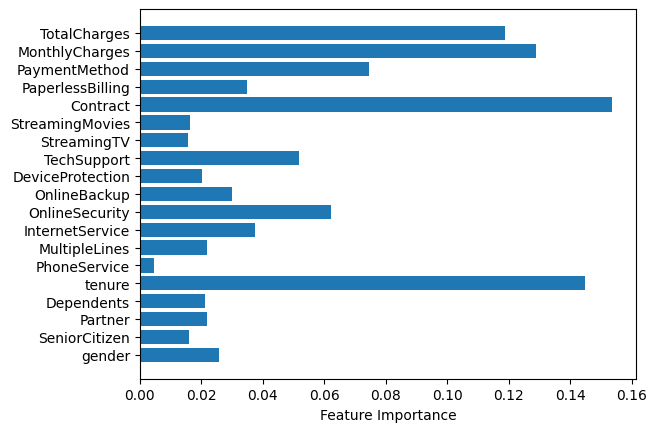

In [15]:
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.show()

Step 9 : Save model

In [17]:
import os

# Check if folder exists, if not create it
if not os.path.exists("models"):
    os.makedirs("models")

In [18]:
import pickle

pickle.dump(best_rf, open("models/rf_model.pkl", "wb"))
pickle.dump(scaler, open("models/scaler.pkl", "wb"))

Step 10 : DEployment via FAST API

In [23]:
from fastapi import FastAPI
import pickle
import numpy as np

app = FastAPI()
model = pickle.load(open("models/rf_model.pkl","rb"))
scaler = pickle.load(open("models/scaler.pkl","rb"))

@app.post("/predict")
def predict(data: dict):
    features = np.array([list(data.values())])
    features_scaled = scaler.transform(features)
    pred = model.predict(features_scaled)[0]
    return {"Churn": bool(pred)}

ModuleNotFoundError: No module named 'fastapi'